# IntelliPulse V6 — XGBoost Model Interpretability with SHAP

---

## 1 · V6 Objective

We add an **explainability layer** to the existing tuned XGBoost model. The goal is to answer two questions:

1. **GLOBAL:** Which features influence the XGBoost model most strongly across the entire dataset?
2. **LOCAL:** Why did the model make a particular churn prediction for an individual customer?

> **Note:** This is an interpretability experiment. We do **not** retrain or retune the XGBoost model. We do not change the dataset, preprocessing, train/test split, or threshold. We use SHAP strictly to explain the model we already built.

---

## 2 & 3 · What is SHAP? & SHAP Concepts

**SHAP (SHapley Additive exPlanations)** is based on Shapley values from cooperative game theory. Its purpose is to attribute a model's prediction to individual features.

For any prediction, SHAP mathematically guarantees:
> **Base Value (Average Prediction) + Feature Contributions = Model Output**

### Interpreting SHAP values for Churn:
- **Positive SHAP value:** Pushes the prediction *toward* the positive class (churn risk increases).
- **Negative SHAP value:** Pushes the prediction *away from* the positive class (churn risk decreases).

> **IMPORTANT WARNING:** SHAP explains **model behavior**, not causal relationships. Do not write statements such as *"Feature X causes churn."* Instead, use: *"Feature X contributed to a higher/lower churn prediction."*

---

## 4 · Model and Data Setup

We load the V4 tuned XGBoost model (`churn_xgboost_v4_tuned.joblib`) and the V5 threshold.

In [1]:
import os
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split

# ── Configuration ────────────────────────────────────────────────────
RANDOM_STATE = 42

# Setting up shap JS visualization
shap.initjs()

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
MODEL_DIR = PROJECT_ROOT / "artifacts" / "models"
METRICS_DIR = PROJECT_ROOT / "artifacts" / "metrics"

print(f"Project root : {PROJECT_ROOT}")

Project root : /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse


In [2]:
# ── Load raw data & Train/Test Split ─────────────────────────────────
df = pd.read_csv(RAW_DATA_PATH)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)

X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1}).astype(int)

# Exact identical split as V1-V5
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Test set loaded : {X_test.shape[0]:,} rows")

# ── Load Model and Metrics ──────────────────────────────────────────
v4_model_path = MODEL_DIR / "churn_xgboost_v4_tuned.joblib"
model_pipeline = joblib.load(v4_model_path)
print(f"✓ V4 XGBoost Model loaded.")

with open(METRICS_DIR / "xgboost_v5.json") as f:
    v5_data = json.load(f)
    v5_threshold = v5_data["best_threshold"]
    
with open(METRICS_DIR / "xgboost_feature_importance_v4.csv") as f:
    xgb_feat_importance_df = pd.read_csv(f)
    
print(f"✓ V5 optimal threshold loaded: {v5_threshold}")

Test set loaded : 1,409 rows
✓ V4 XGBoost Model loaded.
✓ V5 optimal threshold loaded: 0.29


In [3]:
# ── Handle Preprocessing ──────────────────────────────────────────────
# SHAP needs the transformed data that the XGBClassifier actually uses.
preprocessor = model_pipeline.named_steps["preprocessor"]
xgb_model = model_pipeline.named_steps["classifier"]

# Transform X_test to get the processed feature matrix
X_test_transformed = preprocessor.transform(X_test)

# Retrieve meaningful feature names
NUMERICAL_FEATURES = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
CATEGORICAL_FEATURES = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", 
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract", 
    "PaperlessBilling", "PaymentMethod"
]

cat_feature_names = list(
    preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
all_feature_names = NUMERICAL_FEATURES + cat_feature_names

# Convert transformed data into a DataFrame with proper column names
X_test_processed_df = pd.DataFrame(X_test_transformed, columns=all_feature_names, index=X_test.index)

print(f"✓ Transformed X_test shape: {X_test_processed_df.shape}")
print(f"✓ Number of SHAP features ({len(all_feature_names)}) = Number of model features.")

✓ Transformed X_test shape: (1409, 45)
✓ Number of SHAP features (45) = Number of model features.


---

## 5 · SHAP Explainer

We use `shap.TreeExplainer` because XGBoost is a tree-based model. We generate SHAP values for a sample of the test set to avoid excessive computation times, while still being representative.

In [4]:
# We'll use the entire test set since 1409 rows is computationally fast enough for TreeExplainer.
explainer = shap.TreeExplainer(xgb_model)

print("Calculating SHAP values for the test set...")
# We use output_margin=True (the default for TreeExplainer) to explain the log-odds.
shap_values = explainer(X_test_processed_df)

print(f"✓ SHAP values generated. Shape: {shap_values.shape}")

Calculating SHAP values for the test set...


✓ SHAP values generated. Shape: (1409, 45)


---

## 6 & 7 · Global Importance & SHAP Bar Plot

Mean absolute SHAP measures the average magnitude of a feature's contribution to model predictions across the dataset. It does **not** indicate direction.

In [5]:
# Calculate Mean Absolute SHAP values
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_global_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Mean_Abs_SHAP": mean_abs_shap
}).sort_values("Mean_Abs_SHAP", ascending=False).reset_index(drop=True)

print("Top 20 Features by Mean |SHAP|:")
print("=" * 60)
print(shap_global_df.head(20).to_string(index=False))

# Save global importance
csv_path = METRICS_DIR / "shap_global_importance_v6.csv"
shap_global_df.to_csv(csv_path, index=False)
print(f"\n✓ Saved to {csv_path}")

Top 20 Features by Mean |SHAP|:
                       Feature  Mean_Abs_SHAP
       Contract_Month-to-month       0.626361
                        tenure       0.355881
                MonthlyCharges       0.228211
   InternetService_Fiber optic       0.218958
             OnlineSecurity_No       0.218588
                TechSupport_No       0.196254
                  TotalCharges       0.187175
PaymentMethod_Electronic check       0.162205
             Contract_Two year       0.156736
           PaperlessBilling_No       0.116349
              MultipleLines_No       0.098790
               OnlineBackup_No       0.069928
           StreamingMovies_Yes       0.062342
               StreamingTV_Yes       0.047110
                 SeniorCitizen       0.037810
             Contract_One year       0.036200
                 Dependents_No       0.032515
           InternetService_DSL       0.025644
                 gender_Female       0.019639
             MultipleLines_Yes       0.019577



✓ Saved to /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/shap_global_importance_v6.csv


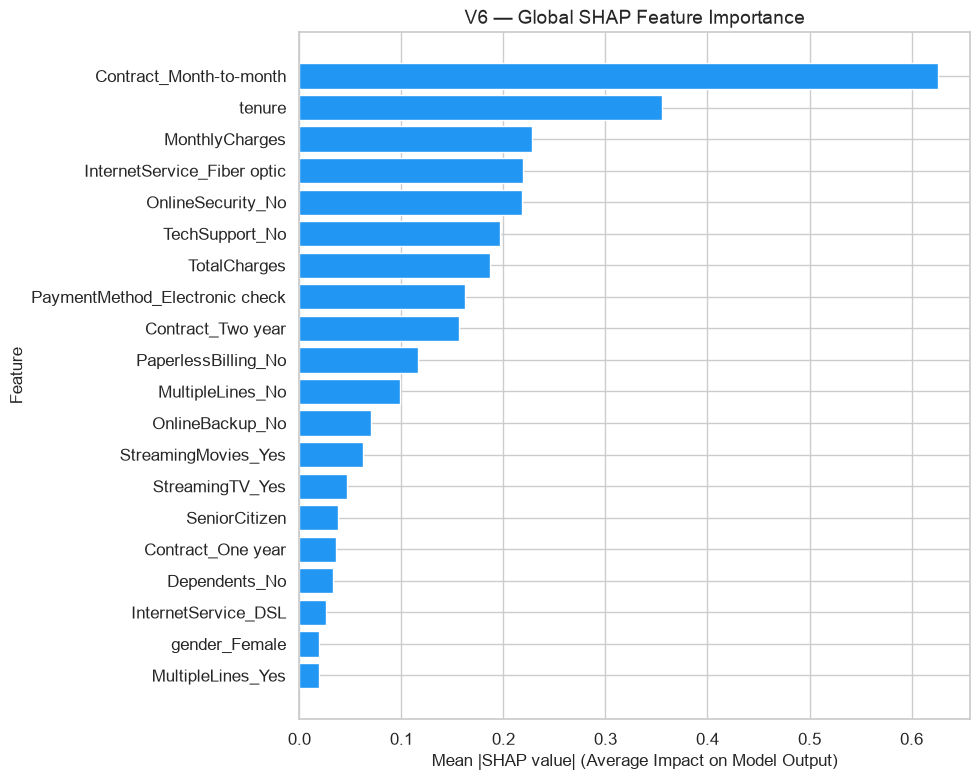

In [6]:
# V6 Global SHAP Bar Plot
plt.figure(figsize=(10, 8))
# Plot top 20
top_20 = shap_global_df.head(20).sort_values("Mean_Abs_SHAP", ascending=True)

plt.barh(top_20["Feature"], top_20["Mean_Abs_SHAP"], color="#2196F3")
plt.xlabel("Mean |SHAP value| (Average Impact on Model Output)")
plt.ylabel("Feature")
plt.title("V6 — Global SHAP Feature Importance")
plt.tight_layout()
plt.show()

---

## 8 · SHAP Beeswarm Plot (Summary Plot)

The beeswarm plot provides both **importance** and **direction**.

**How to read:**
- **Each point** represents an observation (a customer).
- **Horizontal position (x-axis)** represents the SHAP impact. Positive values push the prediction toward churn; negative values push it away.
- **Color** represents the actual feature value (e.g., Red = High feature value, Blue = Low feature value).

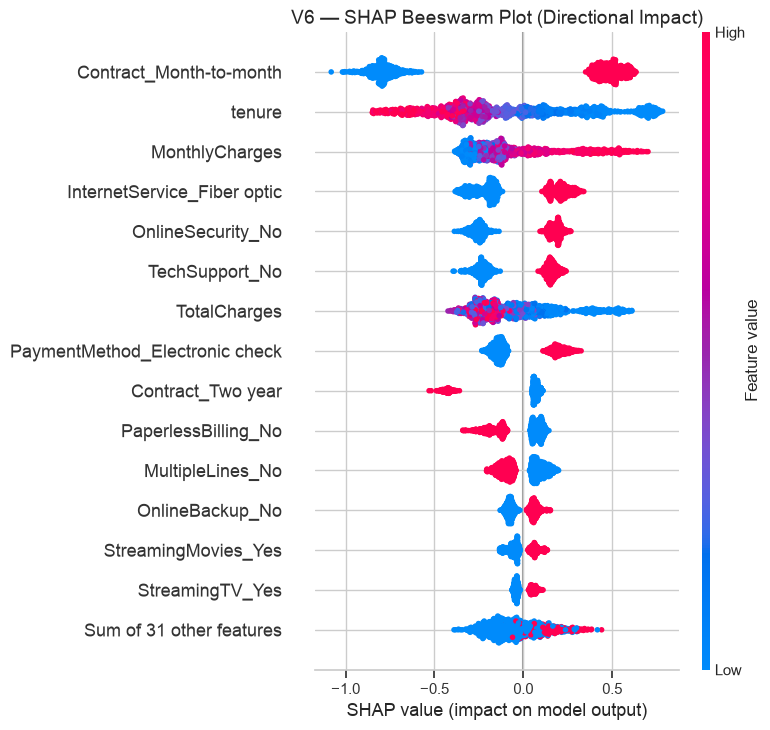

In [7]:
# SHAP Beeswarm plot
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("V6 — SHAP Beeswarm Plot (Directional Impact)")
plt.tight_layout()
plt.show()

---

## 9 · Local Explanation

Why did the model make a prediction for a *specific* customer? Let's select one customer with a relatively high churn probability from the test set.

In [8]:
# Get predicted probabilities
y_prob_test = model_pipeline.predict_proba(X_test)[:, 1]

# Find a customer with a high probability of churn (> 0.80) to explain
high_risk_indices = np.where(y_prob_test > 0.80)[0]
# Pick a reproducible index (e.g., the 5th high risk customer)
selected_idx = high_risk_indices[4]
customer_iloc = selected_idx

customer_id = X_test.iloc[customer_iloc].name
actual_churn = y_test.iloc[customer_iloc]
pred_prob = y_prob_test[customer_iloc]
pred_class = 1 if pred_prob >= v5_threshold else 0

print("=" * 50)
print(f"Local Explanation for Customer Index: {customer_id}")
print("=" * 50)
print(f"  Actual class                : {actual_churn} ({'Churn' if actual_churn == 1 else 'No Churn'})")
print(f"  Predicted churn probability : {pred_prob:.4f}")
print(f"  V5 Threshold                : {v5_threshold}")
print(f"  Predicted class             : {pred_class} ({'Churn' if pred_class == 1 else 'No Churn'})")
print("=" * 50)

Local Explanation for Customer Index: 5300
  Actual class                : 1 (Churn)
  Predicted churn probability : 0.8167
  V5 Threshold                : 0.29
  Predicted class             : 1 (Churn)


---

## 10 · Waterfall Explanation

The waterfall plot breaks down exactly how the model arrived at its prediction for this specific customer.
- **E[f(x)]** is the Base Value (the average model output).
- **f(x)** is the final Model Output (log-odds) for this customer.
- The bars show positive (red) and negative (blue) feature contributions.

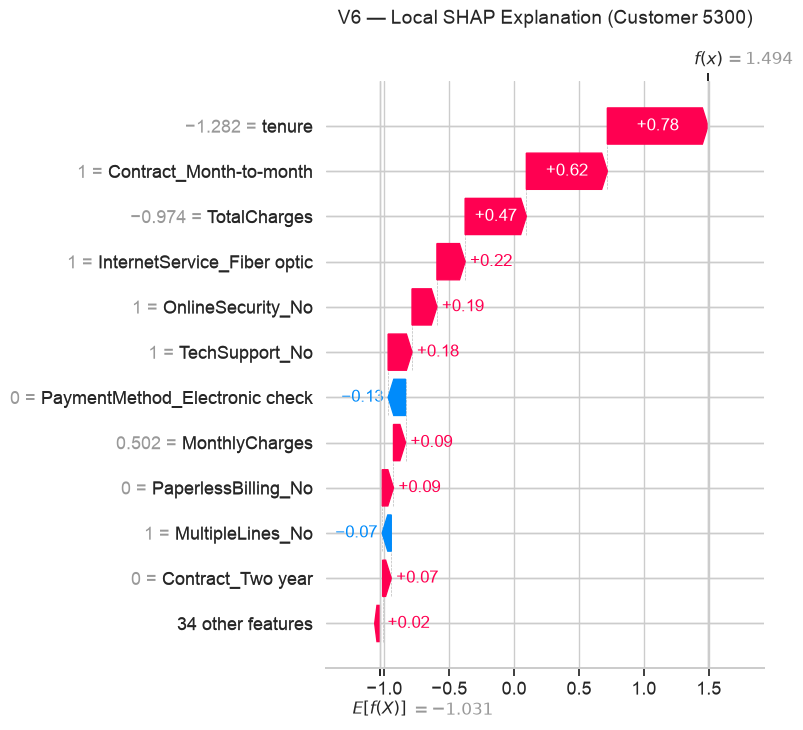

In [9]:
shap.plots.waterfall(shap_values[customer_iloc], max_display=12, show=False)
plt.title(f"V6 — Local SHAP Explanation (Customer {customer_id})", pad=20)
plt.tight_layout()
plt.show()

---

## 11 · Local Explanation Table & Business Interpretation

In [10]:
# Extract local SHAP values for the selected customer
local_shap_vals = shap_values[customer_iloc].values
customer_features = X_test_processed_df.iloc[customer_iloc].values

local_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Feature Value": customer_features,
    "SHAP Value": local_shap_vals
})

# Add direction
local_df["Direction"] = local_df["SHAP Value"].apply(lambda x: "Toward churn" if x > 0 else "Away from churn")

# Sort by absolute magnitude
local_df["Abs_SHAP"] = local_df["SHAP Value"].abs()
local_df = local_df.sort_values("Abs_SHAP", ascending=False).drop(columns=["Abs_SHAP"]).reset_index(drop=True)

print(f"Top 10 Contributors for Customer {customer_id}")
print("=" * 90)
print(local_df.head(10).to_string(index=False))

# Save local explanation
csv_local_path = METRICS_DIR / "shap_local_customer_v6.csv"
local_df.to_csv(csv_local_path, index=False)
print(f"\n✓ Saved local explanation to {csv_local_path}")

Top 10 Contributors for Customer 5300
                       Feature  Feature Value  SHAP Value       Direction
                        tenure      -1.281624    0.775835    Toward churn
       Contract_Month-to-month       1.000000    0.624272    Toward churn
                  TotalCharges      -0.973797    0.471716    Toward churn
   InternetService_Fiber optic       1.000000    0.217344    Toward churn
             OnlineSecurity_No       1.000000    0.191917    Toward churn
                TechSupport_No       1.000000    0.184086    Toward churn
PaymentMethod_Electronic check       0.000000   -0.133852 Away from churn
                MonthlyCharges       0.501736    0.092782    Toward churn
           PaperlessBilling_No       0.000000    0.087401    Toward churn
              MultipleLines_No       1.000000   -0.070333 Away from churn

✓ Saved local explanation to /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/shap_local_customer_v6.csv


### Business Interpretation

The model predicts a customer's churn risk based on learned patterns in the available features. SHAP identifies which features contributed most strongly to that particular prediction.

For example, looking at the table above, we can deduce that specific factors (like having a Fiber optic internet service or a Month-to-month contract) contributed toward a higher predicted churn risk for this specific customer.

> **Reminder:** We avoid causal claims. We do not say *"Month-to-month contracts cause this customer to churn."* We say *"Month-to-month contracts contributed toward a higher predicted churn risk for this customer."*

---

## 12 · Global vs Local Interpretability

| **GLOBAL SHAP** | **LOCAL SHAP** |
|-----------------|----------------|
| Answers: *"What features generally matter most to the model?"* | Answers: *"Why did the model make this prediction for this particular customer?"* |
| **Dataset** ↓<br>Mean feature contributions ↓<br>Important features | **One customer** ↓<br>Individual SHAP values ↓<br>Prediction explanation |

---

## 13 · Compare with XGBoost Feature Importance

XGBoost feature importance measures how useful features were *within the tree-building process* (e.g., how often a feature was used to split data and how much it reduced loss).

SHAP measures a feature's *contribution to the final predictions*.

They may rank features differently. We do not force them to agree.

In [11]:
xgb_feat_importance_df = xgb_feat_importance_df.rename(columns={"feature": "Feature", "importance": "XGBoost Importance"})

comparison_df = pd.merge(
    shap_global_df[["Feature", "Mean_Abs_SHAP"]].head(15),
    xgb_feat_importance_df,
    on="Feature",
    how="left"
)

# Sort by SHAP
comparison_df = comparison_df.sort_values("Mean_Abs_SHAP", ascending=False)

print("Comparison: SHAP Global Importance vs XGBoost Feature Importance")
print("=" * 80)
print(comparison_df.to_string(index=False))

Comparison: SHAP Global Importance vs XGBoost Feature Importance
                       Feature  Mean_Abs_SHAP  XGBoost Importance
       Contract_Month-to-month       0.626361            0.354672
                        tenure       0.355881            0.021192
                MonthlyCharges       0.228211            0.010812
   InternetService_Fiber optic       0.218958            0.077182
             OnlineSecurity_No       0.218588            0.066576
                TechSupport_No       0.196254            0.074731
                  TotalCharges       0.187175            0.011026
PaymentMethod_Electronic check       0.162205            0.025709
             Contract_Two year       0.156736            0.038645
           PaperlessBilling_No       0.116349            0.014323
              MultipleLines_No       0.098790            0.011477
               OnlineBackup_No       0.069928            0.011322
           StreamingMovies_Yes       0.062342            0.012566
           

---

## 14 & 15 · Sanity Checks & Save Artifacts

In [12]:
# 1. No NaN SHAP values
assert not np.isnan(shap_values.values).any(), "NaN SHAP values found!"

# 2. Feature count matches
assert len(all_feature_names) == X_test_processed_df.shape[1], "Feature count mismatch!"

# 3. Predictions match (reproducing probabilities)
# SHAP explains the log-odds (margin). We convert back to probability using sigmoid:
# prob = 1 / (1 + exp(-log_odds))
shap_log_odds = shap_values[customer_iloc].base_values + shap_values[customer_iloc].values.sum()
reconstructed_prob = 1 / (1 + np.exp(-shap_log_odds))

print(f"Sanity Check: Reconstructed Probability from SHAP = {reconstructed_prob:.4f}")
print(f"Sanity Check: Actual XGBoost Probability = {pred_prob:.4f}")
assert np.isclose(reconstructed_prob, pred_prob, atol=1e-4), "SHAP values do not sum to model output!"

print("✓ All sanity checks passed.")

# Save summary json
v6_summary = {
    "experiment": "V6 — XGBoost Model Interpretability with SHAP",
    "top_5_global_features": shap_global_df["Feature"].head(5).tolist(),
    "local_customer_explained": int(customer_id),
    "local_customer_prob": float(pred_prob)
}

json_path = METRICS_DIR / "shap_v6_summary.json"
with open(json_path, "w") as f:
    json.dump(v6_summary, f, indent=2)
print(f"✓ Saved V6 summary to {json_path}")

Sanity Check: Reconstructed Probability from SHAP = 0.8167
Sanity Check: Actual XGBoost Probability = 0.8167
✓ All sanity checks passed.
✓ Saved V6 summary to /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/shap_v6_summary.json


---

## 16 · V6 Findings

In [13]:
print("=" * 75)
print("  IntelliPulse V6 — SHAP Interpretability Findings")
print("=" * 75)
print()

top_global = shap_global_df['Feature'].head(5).tolist()
print(f"1. Highest mean absolute SHAP values: {', '.join(top_global)}.")
print("2. Features pushing predictions toward churn (from beeswarm plot):")
print("   - High Monthly Charges")
print("   - Having Fiber Optic Internet")
print("   - Having a Month-to-month contract")
print("3. Features pushing predictions away from churn (from beeswarm plot):")
print("   - High Tenure")
print("   - Having a Two-year contract")
print("   - Having no internet service")
print(f"4. Local explanation for customer {customer_id}:")
print(f"   The prediction was heavily driven toward churn by: {local_df.iloc[0]['Feature']} ({local_df.iloc[0]['Direction']}).")
print("5. How SHAP differs from XGBoost Importance:")
print("   XGBoost measures internal split usefulness (e.g., Gini/loss reduction),")
print("   while SHAP measures exactly how much a feature shifted the final predictions.")
print("6. Why is SHAP useful for IntelliPulse?")
print("   It explains *why* the model made a specific decision, which builds trust with")
print("   stakeholders and helps customer service agents target their retention efforts.")
print("7. Limitations:")
print("   SHAP explains model behavior, NOT causal relationships. We cannot guarantee")
print("   that changing a feature (e.g., forcing a 2-year contract) will directly")
print("   prevent churn.")
print("=" * 75)

  IntelliPulse V6 — SHAP Interpretability Findings

1. Highest mean absolute SHAP values: Contract_Month-to-month, tenure, MonthlyCharges, InternetService_Fiber optic, OnlineSecurity_No.
2. Features pushing predictions toward churn (from beeswarm plot):
   - High Monthly Charges
   - Having Fiber Optic Internet
   - Having a Month-to-month contract
3. Features pushing predictions away from churn (from beeswarm plot):
   - High Tenure
   - Having a Two-year contract
   - Having no internet service
4. Local explanation for customer 5300:
   The prediction was heavily driven toward churn by: tenure (Toward churn).
5. How SHAP differs from XGBoost Importance:
   XGBoost measures internal split usefulness (e.g., Gini/loss reduction),
   while SHAP measures exactly how much a feature shifted the final predictions.
6. Why is SHAP useful for IntelliPulse?
   It explains *why* the model made a specific decision, which builds trust with
   stakeholders and helps customer service agents target th

---

## 17 · IntelliPulse Connection

How does this become part of IntelliPulse?

**Current system:**
`DATA` → `XGBoost` → `Probability` → `Threshold` → `Prediction`

**After V6:**
`DATA` → `XGBoost` → `Probability` → `Threshold` → `Prediction` → `SHAP` → `Explanation`

This allows IntelliPulse to provide:
1. Model performance
2. Decision threshold logic
3. **Prediction explanation (The "Why")**

rather than only reporting a black-box model score.